In [ ]:
# Clean clinical and aneuploidy heatmap script
# Shortened from the user-provided script.

suppressPackageStartupMessages({
  library(openxlsx)
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(ComplexHeatmap)
  library(circlize)
  library(grid)
})

In [ ]:
# Paths
clinical_dir <- "/home/mjehangir/telomere-sv-analysis/data/"
aneuploidy_dir <- "/scratch/mjehangir/Glioma_project/glioma_aneuploidy/"
#output_file <- "/home/mjehangir/glioma_manuscript/manuscript_data/plots_f1/heatmap_clinical_data_combined_v4.pdf"

In [ ]:
# Sample order
sample_order <- c(
  "3988", "6266D", "6314E", "6324B", "6423A", "6436B", "6500D",
  "2436A", "3188", "6265D", "6269C", "6277A", "6285B", "6298B",
  "6365A", "6414C", "6439C", "6478A", "6483C", "6605D"
)

In [ ]:
# Helpers functions
border_only <- function(j, i, x, y, width, height, fill) {
  grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
}

border_with_label <- function(mat, digits = 2, text_col = "white", fontsize = 8) {
  force(mat)
  function(j, i, x, y, width, height, fill) {
    grid.rect(x, y, width, height, gp = gpar(col = "black", lwd = 0.5, fill = NA))
    grid.text(sprintf(paste0("%.", digits, "f"), mat[i, j]), x = x, y = y,
              gp = gpar(col = text_col, fontsize = fontsize))
  }
}

make_single_heatmap <- function(mat, column, name, col_fun,
                                show_row_names = FALSE,
                                label_values = FALSE) {
  Heatmap(
    matrix = as.matrix(mat[, column, drop = FALSE]),
    name = name,
    col = col_fun,
    cluster_rows = FALSE,
    cluster_columns = FALSE,
    row_names_side = "left",
    show_row_names = show_row_names,
    cell_fun = if (label_values) border_with_label(mat) else border_only
  )
}

In [ ]:
# Clinical data
setwd(clinical_dir)

glioma_data <- read.delim("./clinical_data.txt") %>%
  select(ID, Age, Grade, TP53, ATRX, CDKN2A.B, onco_Alterations, ONT_Alterations) %>%
  arrange(Grade)

glioma_matrix <- as.data.frame(glioma_data)
rownames(glioma_matrix) <- glioma_data$ID

clinical_colors <- list(
  Grade = colorRamp2(c(2, 3), c("tomato1", "tomato3")),
  TP53 = colorRamp2(c(0, 1, 2), c("skyblue3", "skyblue", "white")),
  ATRX = colorRamp2(c(0, 1, 2), c("plum4", "plum1", "white")),
  CDKN2A.B = colorRamp2(c(2, 1), c("white", "darkslategray"))
)

heatmap_grade <- make_single_heatmap(
  mat = glioma_matrix,
  column = "Grade",
  name = "Grade",
  col_fun = clinical_colors$Grade,
  show_row_names = TRUE
)

heatmap_tp53 <- make_single_heatmap(
  mat = glioma_matrix,
  column = "TP53",
  name = "TP53",
  col_fun = clinical_colors$TP53
)

heatmap_atrx <- make_single_heatmap(
  mat = glioma_matrix,
  column = "ATRX",
  name = "ATRX",
  col_fun = clinical_colors$ATRX
)

heatmap_cdkn2ab <- make_single_heatmap(
  mat = glioma_matrix,
  column = "CDKN2A.B",
  name = "CDKN2A/B",
  col_fun = clinical_colors$CDKN2A.B
)

In [8]:
# Aneuploidy summary data
setwd(aneuploidy_dir)

summary_file <- read.csv("/tgen_labs/barthel/projects/Jenkins_Mayo/aneuploidy/Glioma_v2_output_taylor_aneuploidy_summary.txt", header = TRUE, sep = "\t")

summary_file2 <- summary_file %>%
  select(SampleID, prop_aneuploidy, aneuploidy_score, aneuploidy_amp_score, aneuploidy_del_score) %>%
  mutate(SampleID = factor(SampleID, levels = sample_order)) %>%
  arrange(SampleID)

heatmap_matrix <- summary_file2[, -1]
row.names(heatmap_matrix) <- summary_file2$SampleID

score_colors <- list(
  prop = colorRamp2(c(0, 1), c("white", "darkgreen")),
  score = colorRamp2(c(0, max(heatmap_matrix$aneuploidy_score, na.rm = TRUE)), c("white", "lightseagreen")),
  amp = colorRamp2(c(0, max(heatmap_matrix$aneuploidy_amp_score, na.rm = TRUE)), c("white", "darkred")),
  del = colorRamp2(c(0, max(heatmap_matrix$aneuploidy_del_score, na.rm = TRUE)), c("white", "darkblue"))
)

heatmap_prop <- make_single_heatmap(
  mat = heatmap_matrix,
  column = "prop_aneuploidy",
  name = "Prop. Aneuploidy",
  col_fun = score_colors$prop,
  label_values = TRUE
)

heatmap_score <- make_single_heatmap(
  mat = heatmap_matrix,
  column = "aneuploidy_score",
  name = "Aneuploidy Score",
  col_fun = score_colors$score
)

heatmap_amp <- make_single_heatmap(
  mat = heatmap_matrix,
  column = "aneuploidy_amp_score",
  name = "Amp. Score",
  col_fun = score_colors$amp
)

heatmap_del <- make_single_heatmap(
  mat = heatmap_matrix,
  column = "aneuploidy_del_score",
  name = "Del. Score",
  col_fun = score_colors$del
)

In [ ]:
# Display
options(repr.plot.width = 7, repr.plot.height = 5.5, repr.plot.res = 200)
combined_heatmap <- heatmap_grade + heatmap_tp53 + heatmap_atrx + heatmap_cdkn2ab +
  heatmap_score + heatmap_del + heatmap_amp

combined_heatmap

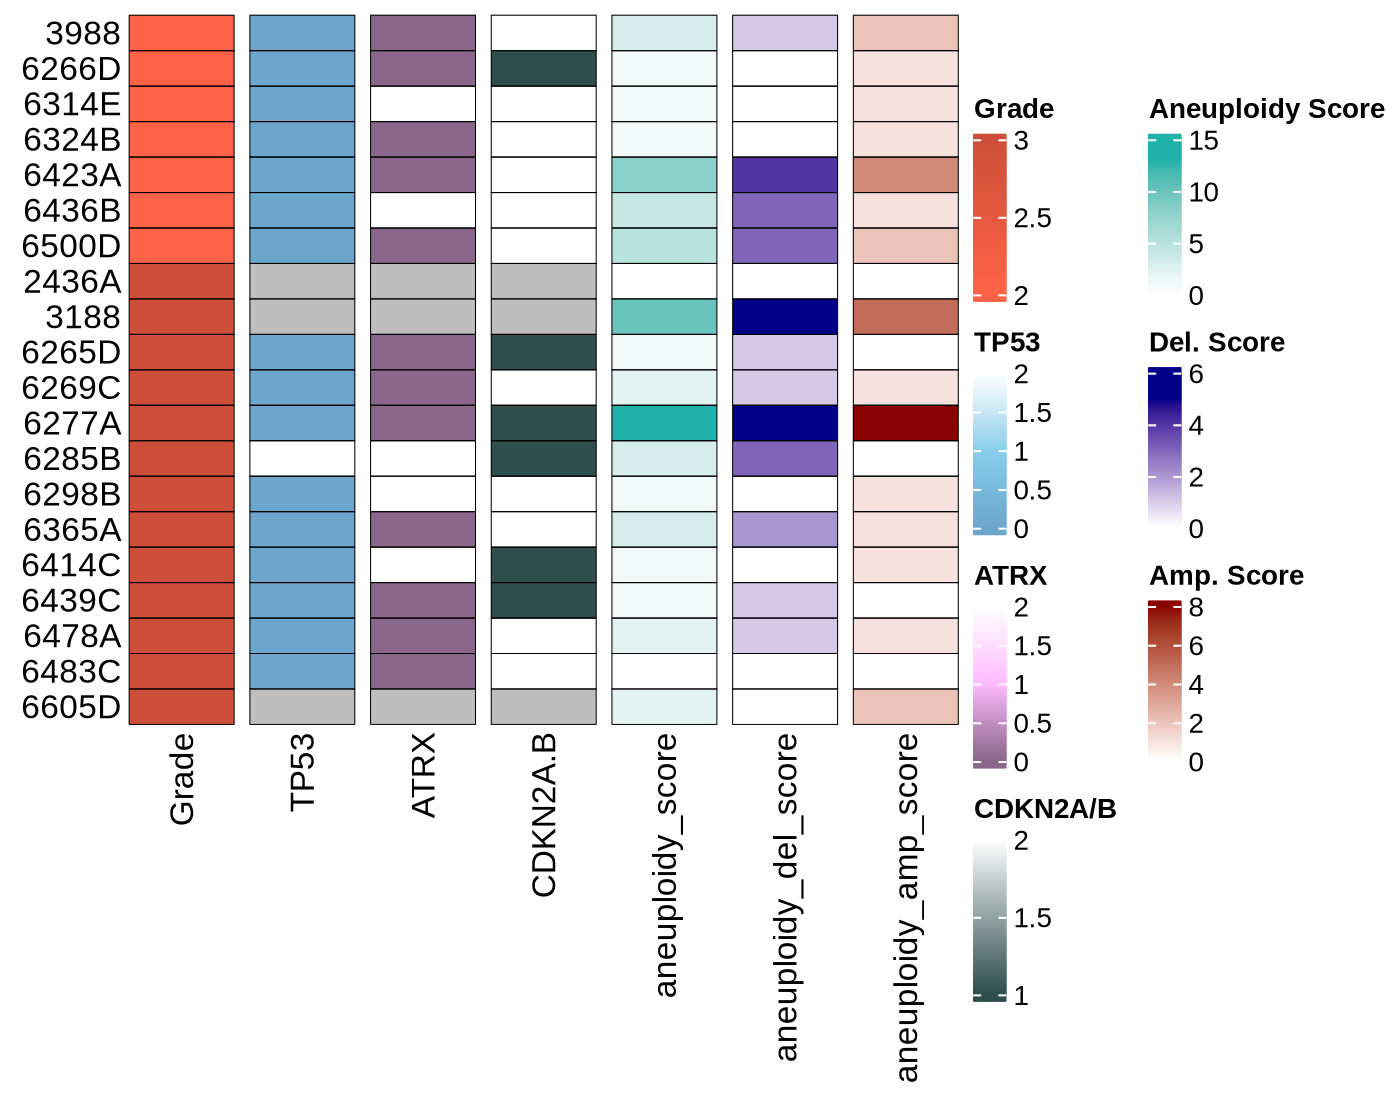

In [7]:
# Save
#pdf(file = output_file, width = 8, height = 6.5)
combined_heatmap
#dev.off()

In [ ]:
options(repr.plot.width = 7.5, repr.plot.height = 5.5, repr.plot.res = 200)

pdf(file = "/home/mjehangir/glioma_manuscript/manuscript_data/plots_f1/heatmap_clinical_data_combined_v4.pdf", width = 8, height = 6.5)
heatmap_Mayo + heatmap_TP53 + heatmap_ATRX + heatmap_CDKN2A_B + heatmap_score  + heatmap_del + heatmap_amp
dev.off()